# **Installation**

In [1]:
%cd /kaggle/working/

# Njoy install
! apt-get install gfortran build-essential -y
! git clone https://github.com/njoy/NJOY2016.git
%cd /kaggle/working/NJOY2016
! cmake -Dstatic=on --build .
! make -j4 install

import os
os.environ['NJOY'] = '/usr/local/bin/njoy'

# install sandy
%cd /kaggle/working/
! git clone --single-branch -b urr_errorr https://github.com/AitorBengoechea/sandy.git
%cd /kaggle/working/sandy
! pip install .

# install openmc
%cd /kaggle/working/
! git clone https://github.com/AI-Pranto/openmc.git --single-branch -b sensitivity
%cd /kaggle/working/openmc
! cmake -DCMAKE_BUILD_TYPE=Release --build .
! make -j4 install
! pip install .

# download data library
%cd /kaggle/working/
! pip install gdown
import gdown
! gdown https://drive.google.com/file/d/1jKzlF58wAFXNWpYHN2HAstNbAlWnMiUG/view?usp=share_link --fuzzy -O - --quiet | tar zxvf -
os.environ['OPENMC_CROSS_SECTIONS'] = '/kaggle/working/mcnp_endfb71/cross_sections.xml'

/kaggle/working
Reading package lists... Done
Building dependency tree       
Reading state information... Done
build-essential is already the newest version (12.8ubuntu1.1).
The following additional packages will be installed:
  gfortran-9 libgfortran-9-dev
Suggested packages:
  gfortran-multilib gfortran-doc gfortran-9-multilib gfortran-9-doc
  libcoarrays-dev
The following NEW packages will be installed:
  gfortran gfortran-9 libgfortran-9-dev
0 upgraded, 3 newly installed, 0 to remove and 115 not upgraded.
Need to get 8622 kB of archives.
After this operation, 33.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu focal-updates/main amd64 libgfortran-9-dev amd64 9.4.0-1ubuntu1~20.04.1 [685 kB]
Get:2 http://archive.ubuntu.com/ubuntu focal-updates/main amd64 gfortran-9 amd64 9.4.0-1ubuntu1~20.04.1 [7936 kB]
Get:3 http://archive.ubuntu.com/ubuntu focal/main amd64 gfortran amd64 4:9.3.0-1ubuntu2 [1372 B]
Fetched 8622 kB in 3s (2612 kB/s)
Selecting previou

# **Input file**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import openmc
import pandas as pd


model = openmc.model.Model()

#--------materials-----------
# 1.6 enriched fuel
fuel = openmc.Material(name='1.6% Fuel')
fuel.set_density('g/cm3', 10.31341)
fuel.add_nuclide('U235', 3.7503e-4)
fuel.add_nuclide('U238', 2.2625e-2)
fuel.add_nuclide('O16', 4.6007e-2)

# zircaloy
zircaloy = openmc.Material(name='Zircaloy')
zircaloy.set_density('g/cm3', 6.55)
zircaloy.add_nuclide('Zr90', 7.2758e-3)

# borated water
water = openmc.Material(name='Borated Water')
water.set_density('g/cm3', 0.740582)
water.add_nuclide('H1', 4.9457e-2)
water.add_nuclide('O16', 2.4732e-2)
water.add_nuclide('B10', 8.0042e-6)

model.materials = openmc.Materials([fuel, water, zircaloy])

#--------geometry---------
# Create cylinders for the fuel and clad
fuel_outer_radius = openmc.ZCylinder(R=0.39218)
clad_outer_radius = openmc.ZCylinder(R=0.45720)

min_x = openmc.XPlane(x0=-10.71, boundary_type='reflective')
max_x = openmc.XPlane(x0=+10.71, boundary_type='vacuum')
min_y = openmc.YPlane(y0=-10.71, boundary_type='vacuum')
max_y = openmc.YPlane(y0=+10.71, boundary_type='reflective')
min_z = openmc.ZPlane(z0=-10.71, boundary_type='reflective')
max_z = openmc.ZPlane(z0=+10.71, boundary_type='reflective')

# Create Cell
fuel_cell = openmc.Cell(name='1.6% Fuel', fill=fuel, region=-fuel_outer_radius)
clad_cell = openmc.Cell(name='1.6% Clad', fill=zircaloy, region = +fuel_outer_radius & -clad_outer_radius)
moderator_cell = openmc.Cell(name='1.6% Moderator', fill=water, region=+clad_outer_radius)

# Create a Universe to encapsulate fuel pin
pin_cell_universe = openmc.Universe(name='1.6% Fuel Pin', cells=[
    fuel_cell, clad_cell, moderator_cell
])
                        
# Create fuel assembly Lattice
assembly = openmc.RectLattice(name='1.6% Fuel - 0BA')
assembly.pitch = (1.26, 1.26)
assembly.lower_left = [-1.26 * 17. / 2.0] * 2
assembly.universes = [[pin_cell_universe] * 17] * 17
root_cell = openmc.Cell(name='root cell', fill=assembly, region = +min_x & -max_x & +min_y & -max_y & +min_z & -max_z)
root_universe = openmc.Universe(name='root universe', cells = [root_cell])
                        
geometry = openmc.Geometry(root_universe)
model.geometry = geometry
                        
#--------------settings------------
settings = openmc.Settings()
settings.batches = 150
settings.inactive = 30
settings.particles = int(10_000)
settings.output = {'tallies': False}
                        
# Create uniform spatial source distribution over fissionable zones
bounds = [-10.71, -10.71, -10, 10.71, 10.71, 10.]
uniform_dist = openmc.stats.Box(bounds[:3], bounds[3:], only_fissionable=True)
settings.source = openmc.Source(space=uniform_dist)

model.settings = settings

#-----sensitivity-------
ll, ur = geometry.bounding_box

mesh = openmc.Mesh(1)
mesh.lower_left = ll
mesh.upper_right = ur
mesh.dimension = (1, 1, 1)

s = openmc.Sensitivity(1)
s.mesh = mesh
s.energies = [1.0000E-05, 3.0000E-03, 7.5000E-03, 1.0000E-02,
                2.5300E-02, 3.0000E-02, 4.0000E-02, 5.0000E-02,
                7.0000E-02, 1.0000E-01, 1.5000E-01, 2.0000E-01,
                2.2500E-01, 2.5000E-01, 2.7500E-01, 3.2500E-01,
                3.5000E-01, 3.7500E-01, 4.0000E-01, 6.2500E-01,
                1.0000E+00, 1.7700E+00, 3.0000E+00, 4.7500E+00,
                6.0000E+00, 8.1000E+00, 1.0000E+01, 3.0000E+01,
                1.0000E+02, 5.5000E+02, 3.0000E+03, 1.7000E+04,
                2.5000E+04, 1.0000E+05, 4.0000E+05, 9.0000E+05,
                1.4000E+06, 1.8500E+06, 2.3540E+06, 2.4790E+06,
                3.0000E+06, 4.8000E+06, 6.4340E+06, 8.1873E+06, 2.0000E+07]

s.nuclides = ['U235', 'U238', 'H1', 'O16', 'Zr90', 'B10']
s.scores = ['total', 'scatter', 'absorption', '(n,2n)', 'fission', 'nubar', 'chi', 'capture', '4', 'elastic']

sensitivities = openmc.Sensitivities([s])
sensitivities.adjoint_method = 'ifp'
sensitivities.ifp_block_length = 10
sensitivities.export_to_xml()

model.export_to_xml()
model.run()


                               %%%%%%%%%%%%%%%
                          %%%%%%%%%%%%%%%%%%%%%%%%
                       %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                     %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                  %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                   %%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                ###############      %%%%%%%%%%%%%%%%%%%%%%%%
               ##################     %%%%%%%%%%%%%%%%%%%%%%%
               ###################     %%%%%%%%%%%%%%%%%%%%%%%
               ####################     %%%%%%%%%%%%%%%%%%%%%%
               #####################     %%%%%%%%%%%%%%%%%%%%%
               ######################     %%%%%%%%%%%%%%%%%%%%
               #######################     %%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%

array([0.68092422, 0.00074312])

In [10]:
! apt-get install dvipng texlive-latex-extra texlive-fonts-recommended cm-super -y
! pip install git+https://github.com/garrettj403/SciencePlots

plt.rcParams.update({
    "font.serif" : "Times New Roman",
    "font.family" : "serif",
    "font.size" : 15,
    "mathtext.fontset" : "stix"
    })

import scienceplots
plt.style.use('science')

with openmc.StatePoint('statepoint.150.h5') as sp:
    for _, sens in sorted(sp.sensitivities.items()):
        df = sens.get_pandas_dataframe()
    

energies = np.array([1.0000E-05, 3.0000E-03, 7.5000E-03, 1.0000E-02,
                    2.5300E-02, 3.0000E-02, 4.0000E-02, 5.0000E-02,
                    7.0000E-02, 1.0000E-01, 1.5000E-01, 2.0000E-01,
                    2.2500E-01, 2.5000E-01, 2.7500E-01, 3.2500E-01,
                    3.5000E-01, 3.7500E-01, 4.0000E-01, 6.2500E-01,
                    1.0000E+00, 1.7700E+00, 3.0000E+00, 4.7500E+00,
                    6.0000E+00, 8.1000E+00, 1.0000E+01, 3.0000E+01,
                    1.0000E+02, 5.5000E+02, 3.0000E+03, 1.7000E+04,
                    2.5000E+04, 1.0000E+05, 4.0000E+05, 9.0000E+05,
                    1.4000E+06, 1.8500E+06, 2.3540E+06, 2.4790E+06,
                    3.0000E+06, 4.8000E+06, 6.4340E+06, 8.1873E+06, 2.0000E+07])


  Cloning https://github.com/garrettj403/SciencePlots to /tmp/pip-req-build-kfdicd8c
  Running command git clone --filter=blob:none --quiet https://github.com/garrettj403/SciencePlots /tmp/pip-req-build-kfdicd8c
  Resolved https://github.com/garrettj403/SciencePlots to commit a55135ac96d065c1ca3e22ce86aaf7c66d7db27d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done


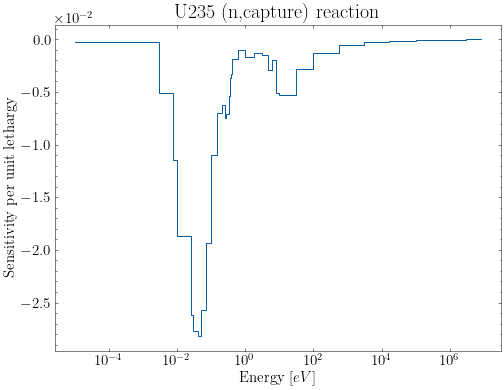

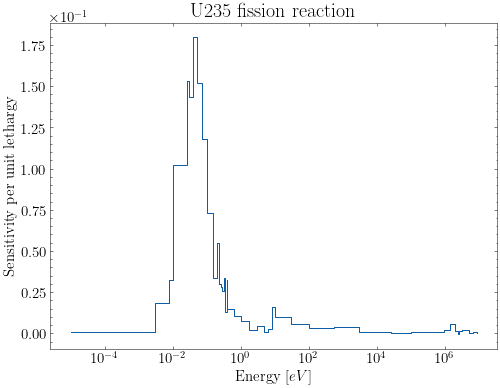

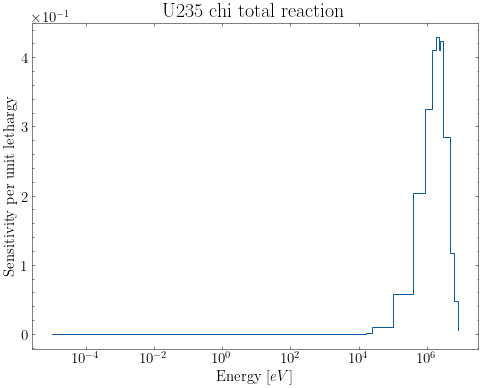

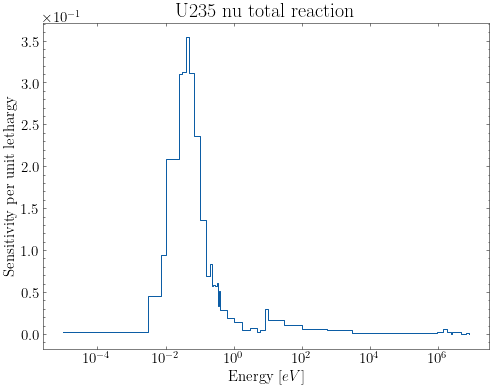

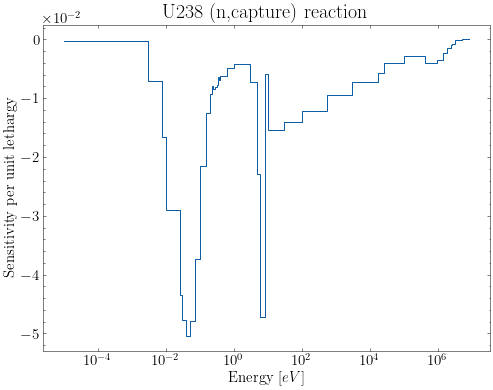

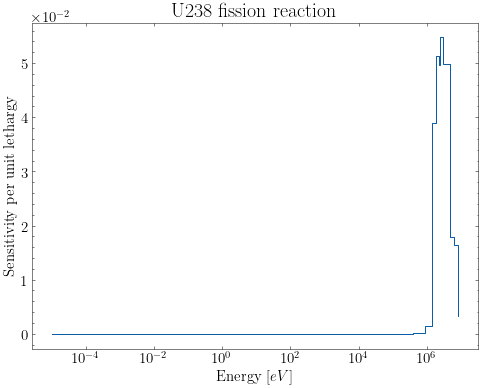

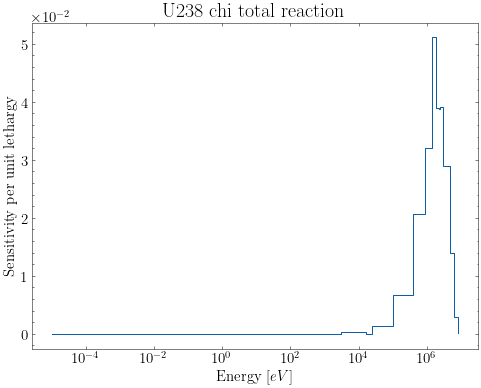

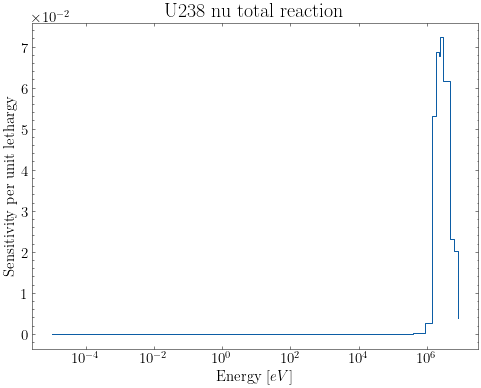

In [18]:
for nuc in ['U235', 'U238']:
    nuclide = df[df['Nuclide'] == nuc]
    for rxn in ['(n,capture)', 'fission', 'chi total', 'nu total']:
        score = nuclide[nuclide['Score'] == rxn]
        sens = score[['mean']].values.ravel()
        sens = sens/(np.log(energies[1:]) - np.log(energies[:-1]))

        fig, ax = plt.subplots(figsize=(8,6))

        ax.step(energies[:-1], sens, where='post')
        ax.set_xscale('log')
        ax.set_title(f'{nuc} {rxn} reaction', fontsize=20)
        ax.set_xlabel(r'Energy $[eV]$')
        ax.set_ylabel('Sensitivity per unit lethargy')
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.show()

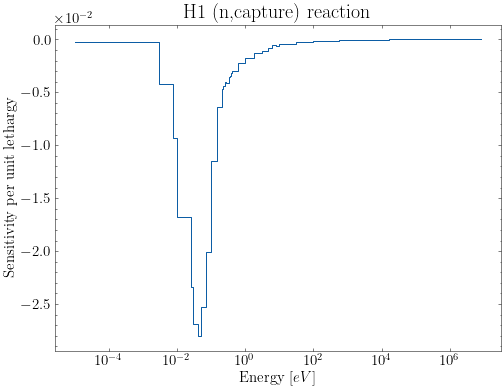

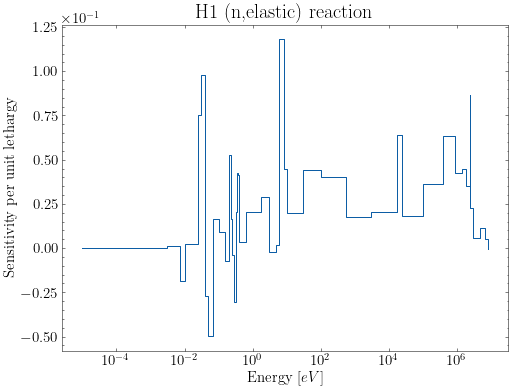

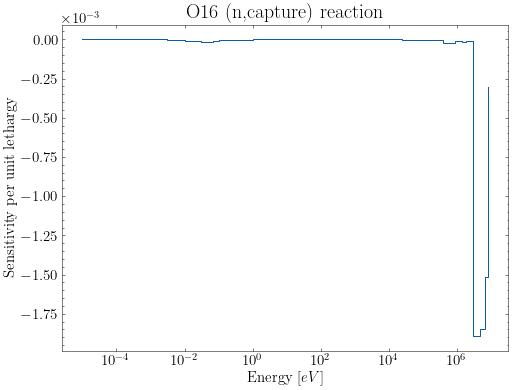

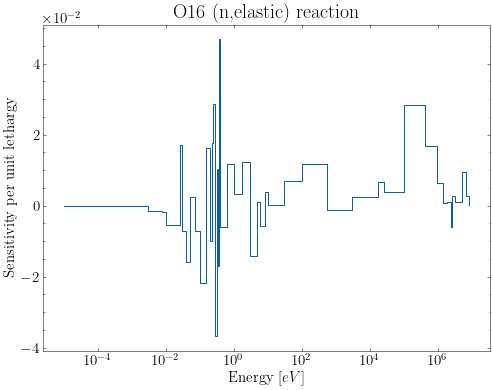

In [19]:
for nuc in ['H1', 'O16']:
    nuclide = df[df['Nuclide'] == nuc]
    for rxn in ['(n,capture)', '(n,elastic)', '(n,level)']:
        score = nuclide[nuclide['Score'] == rxn]
        sens = score[['mean']].values.ravel()
        sens = sens/(np.log(energies[1:]) - np.log(energies[:-1]))

        fig, ax = plt.subplots(figsize=(8,6))

        ax.step(energies[:-1], sens, where='post')
        ax.set_xscale('log')
        ax.set_title(f'{nuc} {rxn} reaction', fontsize=20)
        ax.set_xlabel(r'Energy $[eV]$')
        ax.set_ylabel('Sensitivity per unit lethargy')
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        plt.show()